In [1]:
# 이미 전처리 된 age 데이터에 대한 원본 데이터에서 주름 박스 좌표 추가해야함
'''
1. 전처리 새로 해도 이미 저장된 데이터랑 똑같은지 눈으로 비교
2. 좌표 추가
'''

'\n1. 전처리 새로 해도 이미 저장된 데이터랑 똑같은지 눈으로 비교\n2. 좌표 추가\n'

In [ ]:
import sys
sys.path.append('/home/work/hocheol_dir/workspace/preprocess/age_data/v0.2/v0.2.1-2')
from face_crop_roll2 import age_preprocess
sys.path.append('/home/work/hocheol_dir/workspace/preprocess/age_data/v0.2')
from wrinkle_box import combined_process

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2025-08-29 17:31:14.386894: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-29 17:31:14.452669: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1756456282.509607 2870456 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1756456282.532405 2870456 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1756456282.537117 2870450 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


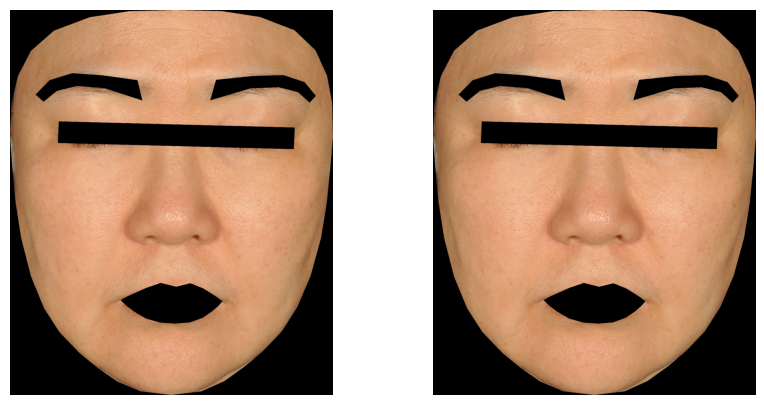

In [3]:
import matplotlib.pyplot as plt
import cv2

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# 새로 전처리한 이미지
cropped_img = age_preprocess('/home/work/hocheol_dir/workspace/datasets/_origin_data/028_data/data/1. 디지털카메라/0001/0001_01_F.jpg')
cropped_img = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB)
axes[0].imshow(cropped_img)
axes[0].axis('off')

# 이미 전처리 되어 저장된 이미지
cropped_already = cv2.imread('/home/work/hocheol_dir/workspace/datasets/new_structure/age_data/v0.2/v0.2_data/028_data/data/0001_01_F.jpg')
cropped_already = cv2.cvtColor(cropped_already, cv2.COLOR_BGR2RGB)
axes[1].imshow(cropped_already)
axes[1].axis('off')

plt.show()
plt.close()

W0000 00:00:1756456480.105469 2871403 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1756456480.123818 2871410 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


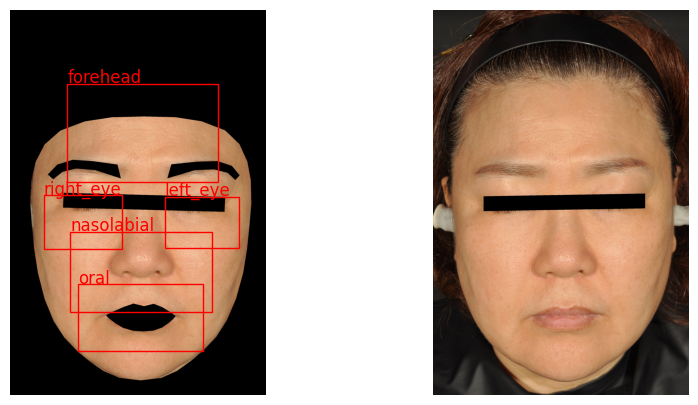

In [8]:
from matplotlib import patches

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

image_path = '/home/work/hocheol_dir/workspace/datasets/_origin_data/028_data/data/1. 디지털카메라/0001/0001_01_F.jpg'
processed_image, boxes, cropped_image, adjusted_boxes = combined_process(image_path)

pure_image = cv2.imread(image_path)

axes[0].imshow(cv2.cvtColor(processed_image, cv2.COLOR_BGR2RGB))
axes[0].axis('off')
for sector, box in boxes.items():
    rect = patches.Rectangle((box['x_min'], box['y_min']), box['x_max'] - box['x_min'], box['y_max'] - box['y_min'], linewidth=1, edgecolor='r', facecolor='none')
    axes[0].add_patch(rect)
    axes[0].text(box['x_min'], box['y_min'] - 5, sector, color='red', fontsize=12)

axes[1].imshow(cv2.cvtColor(pure_image, cv2.COLOR_BGR2RGB))
axes[1].axis('off')

plt.show()

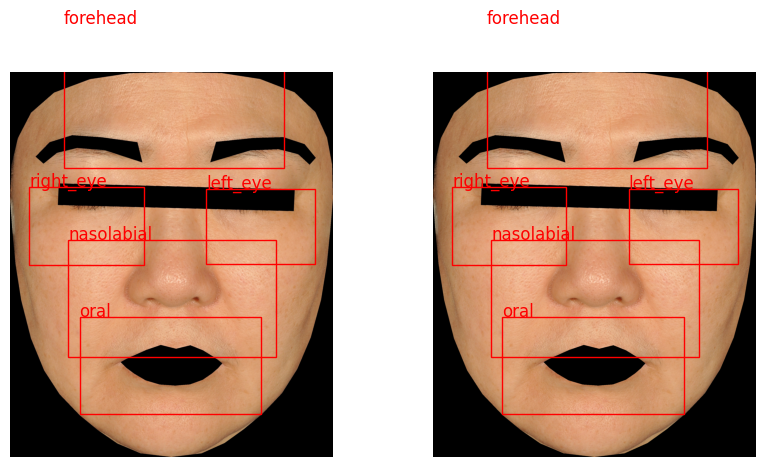

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cropped_already)
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB))
axes[1].axis('off')

for ax in axes:
    for sector, box in adjusted_boxes.items():
        rect = patches.Rectangle((box['x_min'], box['y_min']), box['x_max'] - box['x_min'], box['y_max'] - box['y_min'], linewidth=1, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        ax.text(box['x_min'], box['y_min'] - 5, sector, color='red', fontsize=12)

plt.show()